In [14]:
import numpy as np

def croston_classic(ts, alpha=0.1, n_forecast=7):
    ts = np.array(ts)
    n = len(ts)
    demand = np.where(ts != 0, ts, np.nan)
    interval = np.full_like(ts, np.nan, dtype='float')
    
    # Talep gelen noktalar arası aralık
    last_demand_index = np.nan
    for i in range(n):
        if ts[i] != 0:
            if np.isnan(last_demand_index):
                interval[i] = np.nan
            else:
                interval[i] = i - last_demand_index
            last_demand_index = i

    a_demand = np.nanmean(demand)
    a_interval = np.nanmean(interval)

    forecasts = []
    for _ in range(n_forecast):
        forecasts.append(a_demand / a_interval if a_interval > 0 else 0)

    return forecasts


In [15]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

# 1. Veriyi oku ve hazırla
df = pd.read_excel("../preprocessedBelgeler/NewforecastData_altLimit100_son3_byGrup.xlsx")
df.columns = ['Month', 'SpecGroupId', 'Grade', 'Sipariş Mik. (TON)', 'GradeGroup']
df['Month'] = pd.to_datetime(df['Month'])
df['SpecGroupId'] = df['SpecGroupId'].astype(str)

# Aylık Grade bazlı toplam talep
monthly_grade = df.groupby(['Month', 'GradeGroup'])['Sipariş Mik. (TON)'].sum().reset_index()
grade_list = monthly_grade['GradeGroup'].unique()

forecast_df = pd.DataFrame()
disaggregated_df = pd.DataFrame()
mae_list = []
mape_list = []

for grade in grade_list:
    # 2. Grade bazlı zaman serisini oluştur
    grade_data = monthly_grade[monthly_grade['GradeGroup'] == grade].set_index('Month')
    grade_data = grade_data.loc['2022-01':'2024-06']  # Eğitim verisi
    y_train = grade_data['Sipariş Mik. (TON)'].asfreq('MS').fillna(0).values

    # Eğer sabit ya da boş seri ise atla
    if np.std(y_train) < 1e-3 or np.sum(y_train) == 0:
        print(f"'{grade}' atlandı çünkü zaman serisi sabit veya boş.")
        continue

    # 3. Croston tahmini
    forecast_vals = croston_classic(y_train, alpha=0.1, n_forecast=8)

    forecast_index = pd.date_range(start='2024-07-01', periods=8, freq='MS')
    
    # 4. Tahmini df'e yaz
    temp_forecast = pd.DataFrame({
        'Month': forecast_index,
        'GradeGroup': grade,
        'Forecast_TON': forecast_vals[-8:]
    })
    forecast_df = pd.concat([forecast_df, temp_forecast], ignore_index=True)

    # 5. Disaggregation (SpecGroupId'lere dağıtım)
    for month, forecast_ton in zip(forecast_index, forecast_vals[-8:]):
        # Aynı ayın geçmiş yıllarındaki dağılım oranlarını kullan
        past_months = df[(df['GradeGroup'] == grade) & (df['Month'].dt.month == month.month)]
        past_months_total = past_months.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()
        total = past_months_total.sum()

        if total == 0:  # fallback
            past_months = df[df['GradeGroup'] == grade]
            past_months_total = past_months.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()
            total = past_months_total.sum()

        if total == 0:
            print(f"{grade} için {month.strftime('%Y-%m')} ayında geçmiş veri bulunamadı.")
            continue

        proportions = past_months_total / total
        disagg = proportions * forecast_ton

        for spec_id, miktar in disagg.items():
            disaggregated_df = pd.concat([disaggregated_df, pd.DataFrame({
                'Month': [month],
                'GradeGroup': [grade],
                'SpecGroupId': [spec_id],
                'Forecast_TON': [miktar]
            })])

        # 6. Gerçeklerle kıyas
        actual_df = df[(df['Month'] == month) & (df['GradeGroup'] == grade)]
        actual_agg = actual_df.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()

        forecast_agg = disaggregated_df[
            (disaggregated_df['Month'] == month) &
            (disaggregated_df['GradeGroup'] == grade)
        ].groupby('SpecGroupId')['Forecast_TON'].sum()

        common_index = actual_agg.index.intersection(forecast_agg.index)

        if len(common_index) > 0:
            actual_vals = actual_agg.loc[common_index]
            pred_vals = forecast_agg.loc[common_index]

            for spec_id in common_index:
                disagg_metrics = {
                    'GradeGroup': grade,
                    'Month': month,
                    'SpecGroupId': spec_id,
                    'MAE_Disagg': abs(actual_vals[spec_id] - pred_vals[spec_id]),
                    'MAPE_Disagg': abs((actual_vals[spec_id] - pred_vals[spec_id]) / actual_vals[spec_id]) if actual_vals[spec_id] != 0 else np.nan
                }
                mae_list.append(disagg_metrics)

# → forecast_df = grade bazlı tahminler
# → disaggregated_df = specGroupId bazlı dağılmış tahminler
# → mae_list = hata metrikleri



/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_28204/4001759909.py:20: RuntimeWarning: Mean of empty slice
  a_interval = np.nanmean(interval)
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_28204/4001759909.py:20: RuntimeWarning: Mean of empty slice
  a_interval = np.nanmean(interval)


In [16]:
"""import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

# 1. Veriyi oku ve hazırla
df = pd.read_excel("../preprocessedBelgeler/NewforecastData_altLimit100_son3_byGrup.xlsx")
df.columns = ['Month', 'SpecGroupId', 'Grade', 'Sipariş Mik. (TON)', 'GradeGroup']
df['Month'] = pd.to_datetime(df['Month'])
df['SpecGroupId'] = df['SpecGroupId'].astype(str)

# Aylık Grade bazlı toplam talep
monthly_grade = df.groupby(['Month', 'GradeGroup'])['Sipariş Mik. (TON)'].sum().reset_index()
grade_list = monthly_grade['GradeGroup'].unique()

forecast_df = pd.DataFrame()
disaggregated_df = pd.DataFrame()
mae_list = []
mape_list = []

for grade in grade_list:
    # 2. Grade bazlı zaman serisini oluştur
    grade_data = monthly_grade[monthly_grade['GradeGroup'] == grade].set_index('Month')
    grade_data = grade_data.loc['2022-01':'2025-02']  # Eğitim verisi
    y_train = grade_data['Sipariş Mik. (TON)'].asfreq('MS').fillna(0).values

    # Eğer sabit ya da boş seri ise atla
    if np.std(y_train) < 1e-3 or np.sum(y_train) == 0:
        print(f"'{grade}' atlandı çünkü zaman serisi sabit veya boş.")
        continue

    # 3. Croston tahmini
    forecast_vals = croston_classic(y_train, alpha=0.1, n_forecast=3)

    forecast_index = pd.date_range(start='2025-03-01', periods=3, freq='MS')
    
    # 4. Tahmini df'e yaz
    temp_forecast = pd.DataFrame({
        'Month': forecast_index,
        'GradeGroup': grade,
        'Forecast_TON': forecast_vals[-3:]
    })
    forecast_df = pd.concat([forecast_df, temp_forecast], ignore_index=True)

    # 5. Disaggregation (SpecGroupId'lere dağıtım)
    for month, forecast_ton in zip(forecast_index, forecast_vals[-3:]):
        # Aynı ayın geçmiş yıllarındaki dağılım oranlarını kullan
        past_months = df[(df['GradeGroup'] == grade) & (df['Month'].dt.month == month.month)]
        past_months_total = past_months.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()
        total = past_months_total.sum()

        if total == 0:  # fallback
            past_months = df[df['GradeGroup'] == grade]
            past_months_total = past_months.groupby('SpecGroupId')['Sipariş Mik. (TON)'].sum()
            total = past_months_total.sum()

        if total == 0:
            print(f"{grade} için {month.strftime('%Y-%m')} ayında geçmiş veri bulunamadı.")
            continue

        proportions = past_months_total / total
        disagg = proportions * forecast_ton

        for spec_id, miktar in disagg.items():
            disaggregated_df = pd.concat([disaggregated_df, pd.DataFrame({
                'Month': [month],
                'GradeGroup': [grade],
                'SpecGroupId': [spec_id],
                'Forecast_TON': [miktar]
            })])
disaggregated_df.to_excel('../results/CROSTON_forecast.xlsx', index=False)
"""

'import pandas as pd\nimport numpy as np\nfrom sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error\nimport matplotlib.pyplot as plt\n\n# 1. Veriyi oku ve hazırla\ndf = pd.read_excel("../preprocessedBelgeler/NewforecastData_altLimit100_son3_byGrup.xlsx")\ndf.columns = [\'Month\', \'SpecGroupId\', \'Grade\', \'Sipariş Mik. (TON)\', \'GradeGroup\']\ndf[\'Month\'] = pd.to_datetime(df[\'Month\'])\ndf[\'SpecGroupId\'] = df[\'SpecGroupId\'].astype(str)\n\n# Aylık Grade bazlı toplam talep\nmonthly_grade = df.groupby([\'Month\', \'GradeGroup\'])[\'Sipariş Mik. (TON)\'].sum().reset_index()\ngrade_list = monthly_grade[\'GradeGroup\'].unique()\n\nforecast_df = pd.DataFrame()\ndisaggregated_df = pd.DataFrame()\nmae_list = []\nmape_list = []\n\nfor grade in grade_list:\n    # 2. Grade bazlı zaman serisini oluştur\n    grade_data = monthly_grade[monthly_grade[\'GradeGroup\'] == grade].set_index(\'Month\')\n    grade_data = grade_data.loc[\'2022-01\':\'2025-02\']  # Eğitim veris

In [17]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import numpy as np
import pandas as pd

# 🎯 Grade bazlı performans metriklerini hesapla
grade_metrics = []

# forecast_df: grade bazlı Croston tahminleri (Month, Grade, Forecast_TON)
# monthly_grade: gerçek değerler (Month, Grade, Sipariş Mik. (TON))

for grade in forecast_df['GradeGroup'].unique():
    # Tahmin edilen veriler
    pred_series = forecast_df[forecast_df['GradeGroup'] == grade].set_index('Month')['Forecast_TON']
    
    # Gerçek veriler
    actual_series = monthly_grade[monthly_grade['GradeGroup'] == grade].set_index('Month')['Sipariş Mik. (TON)']
    
    # Ortak aylar
    common_months = pred_series.index.intersection(actual_series.index)
    
    if len(common_months) == 0:
        continue

    y_true = actual_series.loc[common_months]
    y_pred = pred_series.loc[common_months]

    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
    wmape = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))

    grade_metrics.append({
        'GradeGroup': grade,
        'MAE': mae,
        'MAPE (%)': mape,
        'sMAPE (%)': smape,
        'wMAPE (%)': wmape,
        'RMSE': rmse
    })

# 🎉 Sonuçları tablo olarak göster
grade_metrics_df = pd.DataFrame(grade_metrics)
print("\n📊 Croston – Grade Bazlı Tahmin Performansı:")
print(grade_metrics_df)

# Kaydetmek istersen:
# grade_metrics_df.to_excel("croston_grade_metrics_summary.xlsx", index=False)



📊 Croston – Grade Bazlı Tahmin Performansı:
    GradeGroup           MAE      MAPE (%)   sMAPE (%)     wMAPE (%)  \
0            A  18082.719875  5.860827e+01   39.987106  3.689078e+01   
1            B     95.018750  2.550015e+19   96.165038  7.978316e+01   
2            C    405.042500  1.644433e+20  190.486262  3.304446e+03   
3            D   1480.549000  2.867142e+02   88.281855  7.559696e+01   
4         DD11   2701.347552  1.066469e+21  199.274625  5.424393e+04   
5       DD11-1   6678.421250  3.007694e+21  200.000000           inf   
6       DD11-2    366.035600  1.648478e+20  200.000000           inf   
7         DD13     64.252444  2.893673e+19  200.000000           inf   
8            E    130.918918  4.810809e+19  177.791894  5.245674e+02   
9       P265NB      0.000000  0.000000e+00         NaN           NaN   
10      S235JR  13574.354376  5.354587e+21  199.599172  9.889339e+04   
11    S235JR-1   1390.084179  5.488135e+20  199.260403  5.318352e+04   
12  S235JR-CL3     

/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_28204/1102543440.py:31: RuntimeWarning: divide by zero encountered in double_scalars
  wmape = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_28204/1102543440.py:31: RuntimeWarning: divide by zero encountered in double_scalars
  wmape = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_28204/1102543440.py:31: RuntimeWarning: divide by zero encountered in double_scalars
  wmape = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_28204/1102543440.py:31: RuntimeWarning: invalid value encountered in double_scalars
  wmape = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_28204/1102543440.py:31: RuntimeWarning: invalid value encountered in doubl

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np
import pandas as pd

# 🎯 1. Gerçek veriyi filtrele
actual_all = monthly_grade[
    (monthly_grade['Month'] >= '2024-06') & 
    (monthly_grade['Month'] <= '2025-02')
]

# 🎯 2. Tahmin ile birleştir
merged_all = pd.merge(
    actual_all, 
    forecast_df, 
    on=['Month', 'GradeGroup'], 
    how='inner'
)

# 🎯 3. NaN'leri at
merged_all.dropna(subset=['Sipariş Mik. (TON)', 'Forecast_TON'], inplace=True)

# 🎯 4. Hedef serileri
y_true_all = merged_all['Sipariş Mik. (TON)']
y_pred_all = merged_all['Forecast_TON']

# 🎯 5. Hata metrikleri
mae_all = mean_absolute_error(y_true_all, y_pred_all)
mape_all = mean_absolute_percentage_error(y_true_all, y_pred_all) * 100
rmse_all = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
smape_all = 100 * np.mean(2 * np.abs(y_pred_all - y_true_all) / (np.abs(y_true_all) + np.abs(y_pred_all)))
wmape_all = 100 * np.sum(np.abs(y_pred_all - y_true_all)) / np.sum(np.abs(y_true_all))

# 📢 6. Yazdır
print("\n📦 Tüm GradeGroup'ler için TOPLAM tahmin performansı:")
print(f"MAE   : {mae_all:.2f}")
print(f"MAPE  : {mape_all:.2f}%")
print(f"sMAPE : {smape_all:.2f}%")
print(f"wMAPE : {wmape_all:.2f}%")
print(f"RMSE  : {rmse_all:.2f}")



📦 Tüm GradeGroup'ler için TOPLAM tahmin performansı:
MAE   : 2825.49
MAPE  : 657001005412820320256.00%
sMAPE : 168.08%
wMAPE : 88.33%
RMSE  : 6453.68


⏳ 2024-07 ayı için CROSTON grafiği hazırlanıyor...


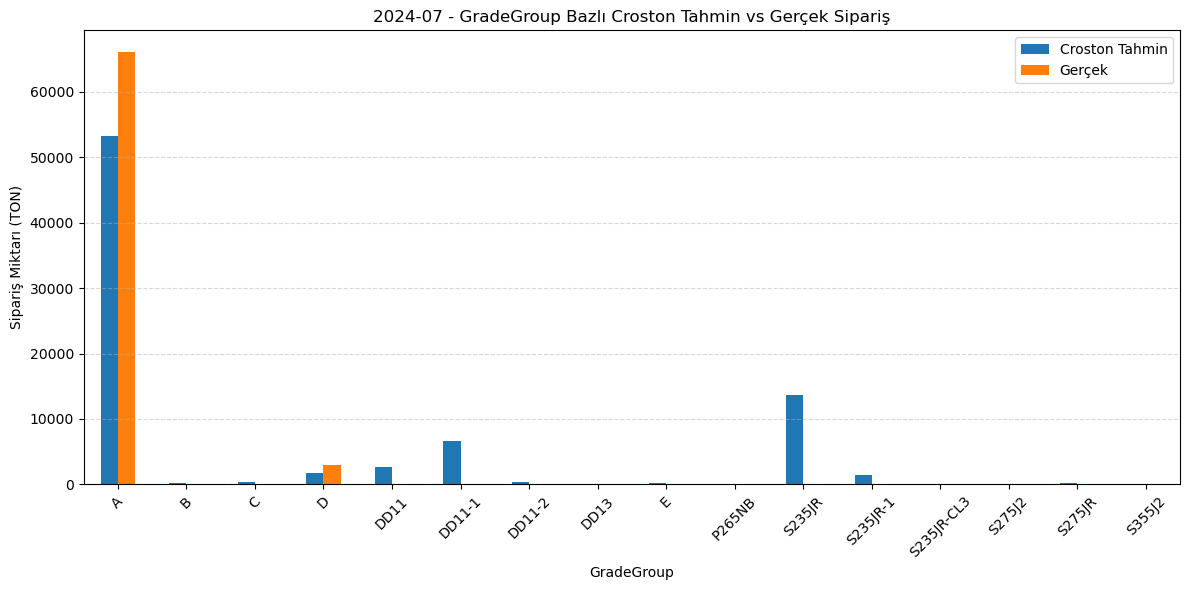

⏳ 2024-08 ayı için CROSTON grafiği hazırlanıyor...


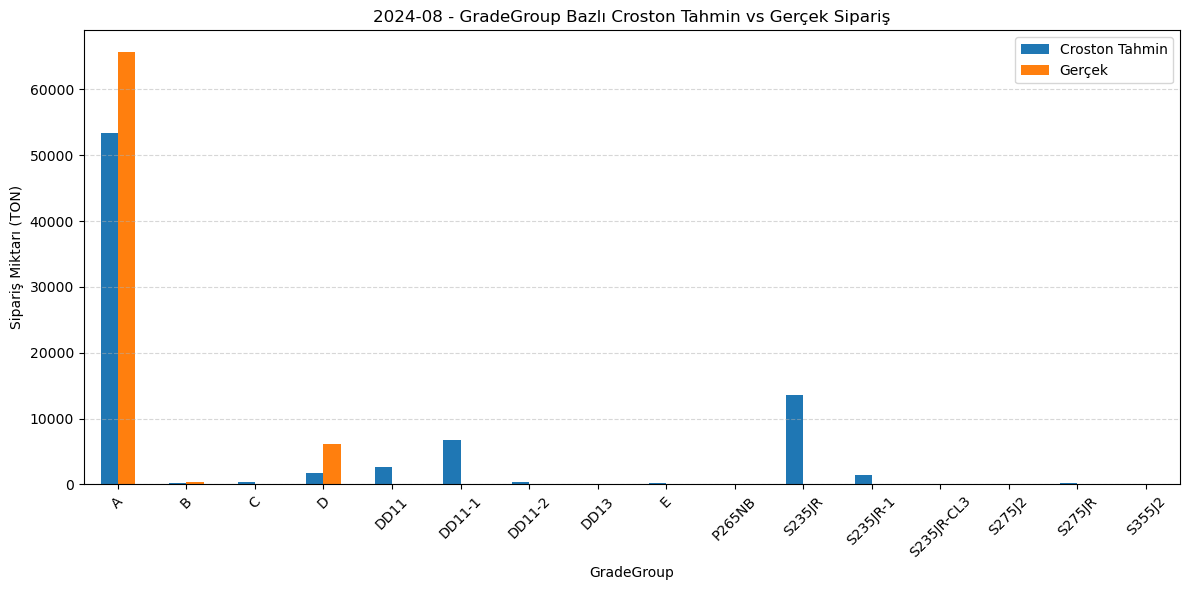

⏳ 2024-09 ayı için CROSTON grafiği hazırlanıyor...


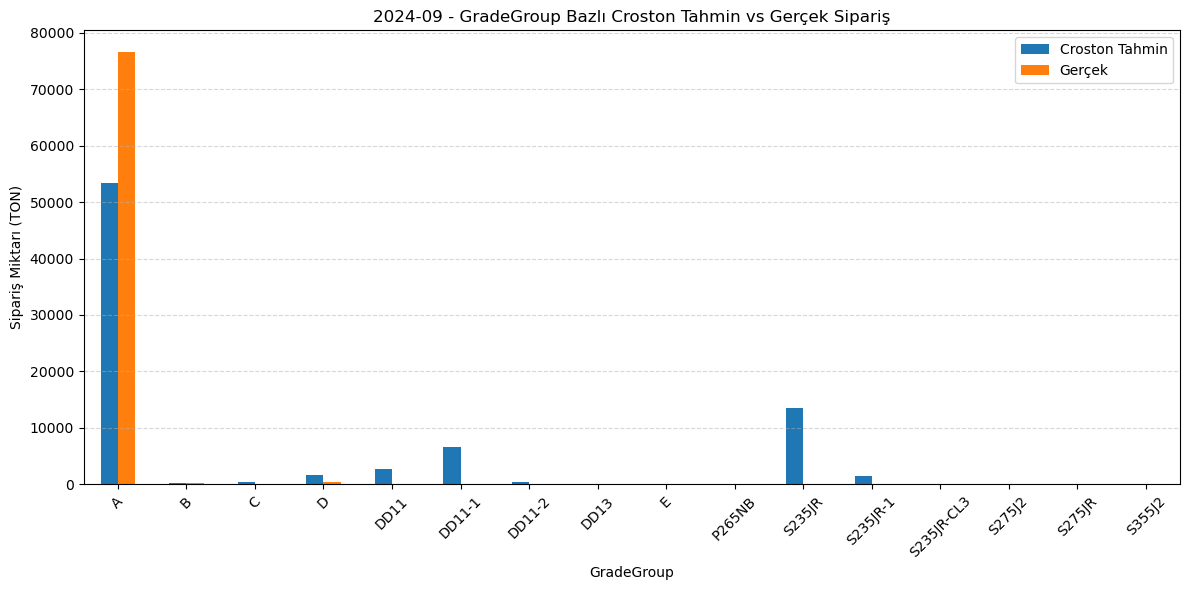

⏳ 2024-10 ayı için CROSTON grafiği hazırlanıyor...


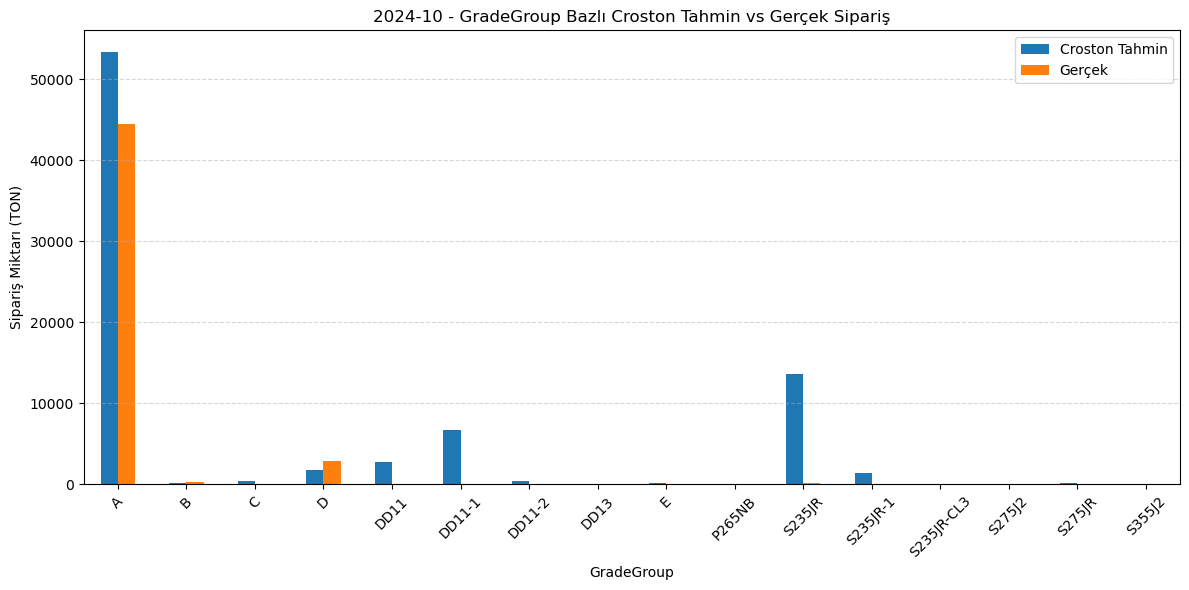

⏳ 2024-11 ayı için CROSTON grafiği hazırlanıyor...


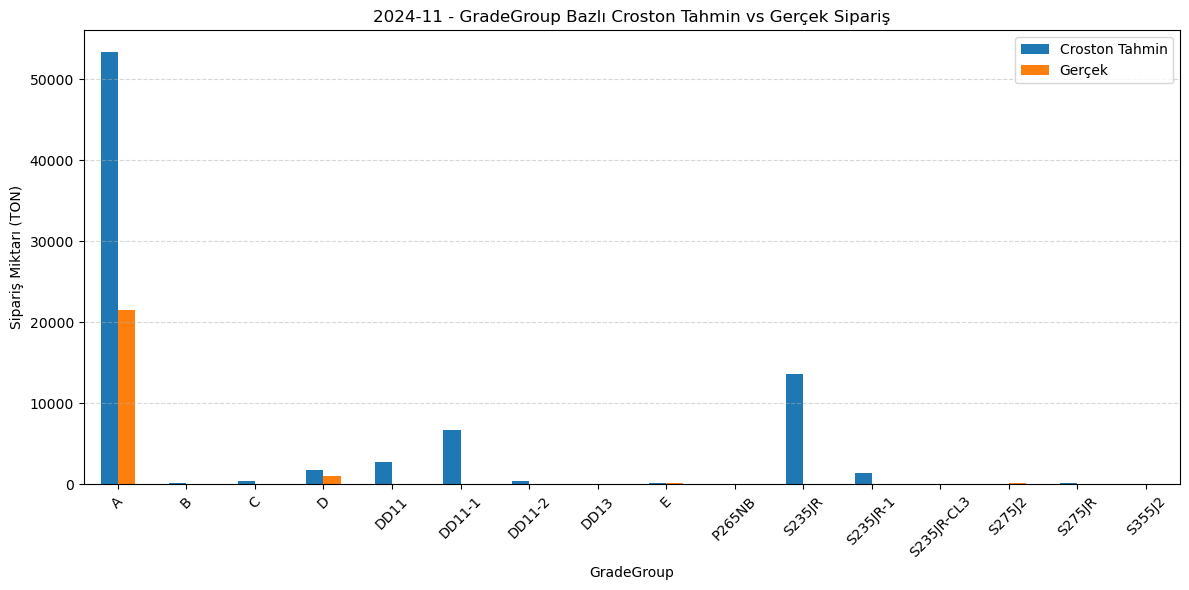

⏳ 2024-12 ayı için CROSTON grafiği hazırlanıyor...


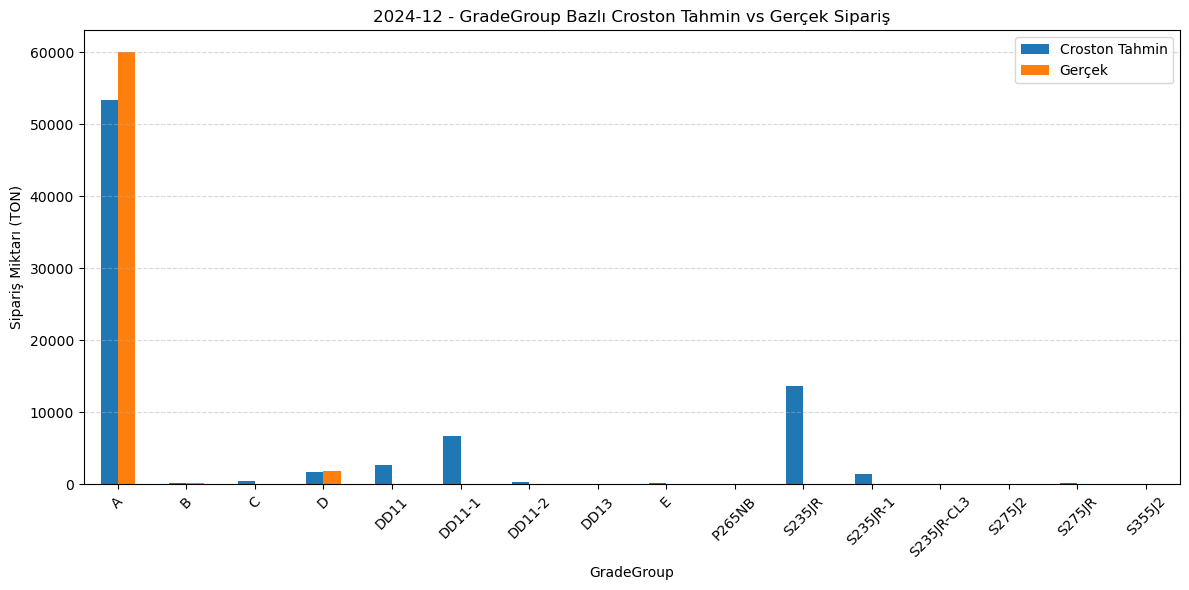

⏳ 2025-01 ayı için CROSTON grafiği hazırlanıyor...


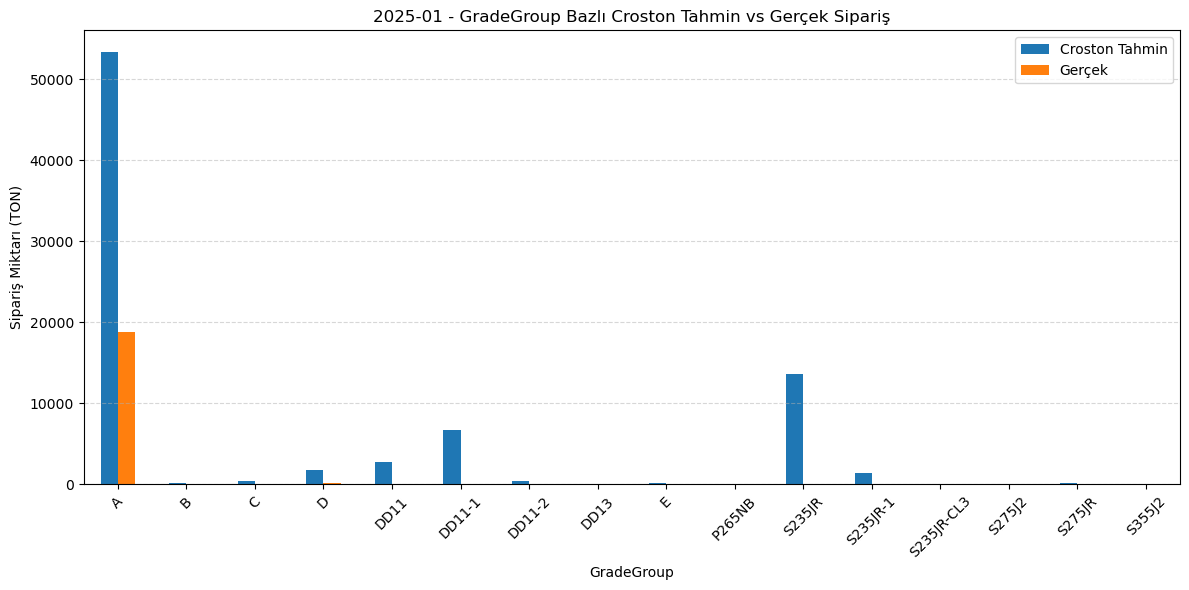

⏳ 2025-02 ayı için CROSTON grafiği hazırlanıyor...


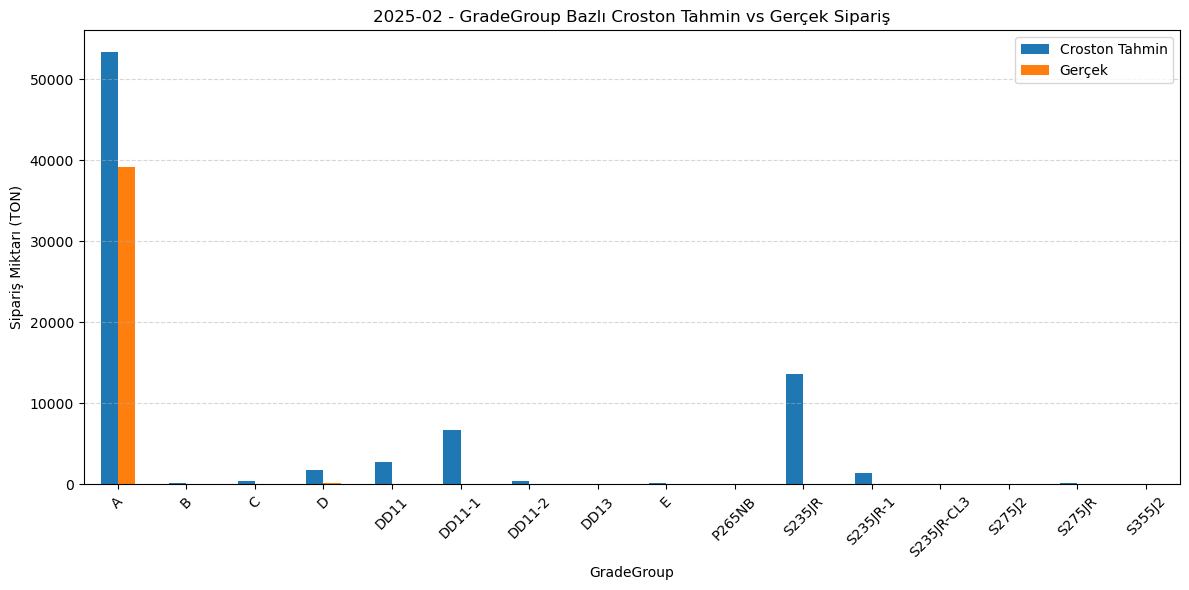

In [19]:
import matplotlib.pyplot as plt

# 🎯 Hedef aylar
target_months = ['2024-07','2024-08', '2024-09', '2024-10','2024-11','2024-12','2025-01','2025-02']

for month in target_months:
    print(f"⏳ {month} ayı için CROSTON grafiği hazırlanıyor...")

    forecast_m = forecast_df[forecast_df['Month'] == month]  # ← Croston forecast
    actual_m = monthly_grade[monthly_grade['Month'] == month]  # Gerçek değerler

    # Verileri aynı forma sok
    forecast_m = forecast_m[['GradeGroup', 'Forecast_TON']].set_index('GradeGroup')
    actual_m = actual_m[['GradeGroup', 'Sipariş Mik. (TON)']].set_index('GradeGroup')

    # Ortak grade'leri al
    common_grades = forecast_m.index.intersection(actual_m.index)

    if len(common_grades) == 0:
        print(f"⚠️ {month} için hem tahmin hem gerçek veri yok.")
        continue

    compare_df = pd.DataFrame({
        'Forecast (Croston)': forecast_m.loc[common_grades]['Forecast_TON'],
        'Actual': actual_m.loc[common_grades]['Sipariş Mik. (TON)']
    }).sort_index()

    # Bar chart
    compare_df.plot(kind='bar', figsize=(12,6), color=['#1f77b4', '#ff7f0e'])
    plt.title(f"{month} - GradeGroup Bazlı Croston Tahmin vs Gerçek Sipariş")
    plt.ylabel("Sipariş Miktarı (TON)")
    plt.xlabel("GradeGroup")
    plt.xticks(rotation=45)
    plt.legend(["Croston Tahmin", "Gerçek"])
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()


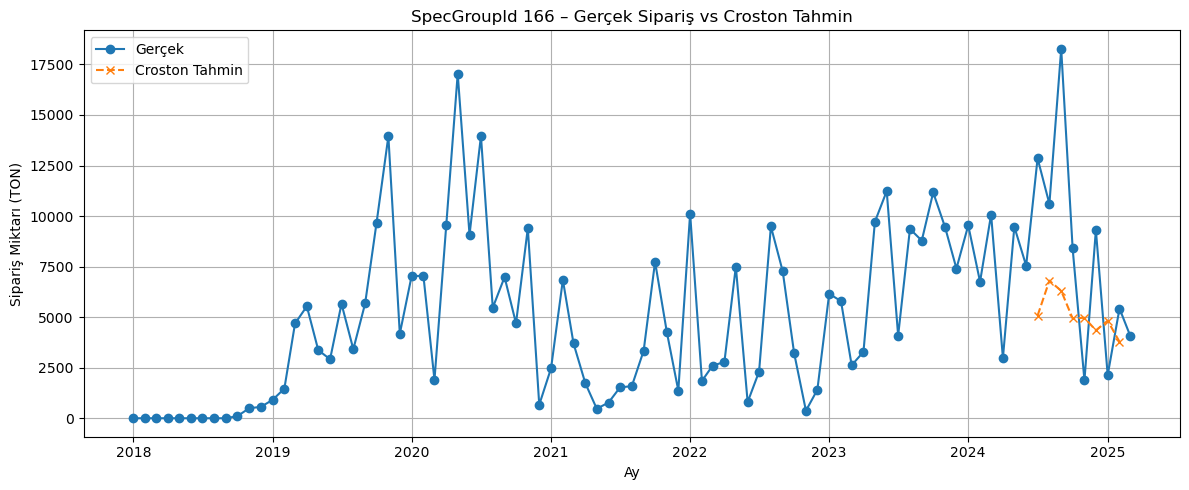

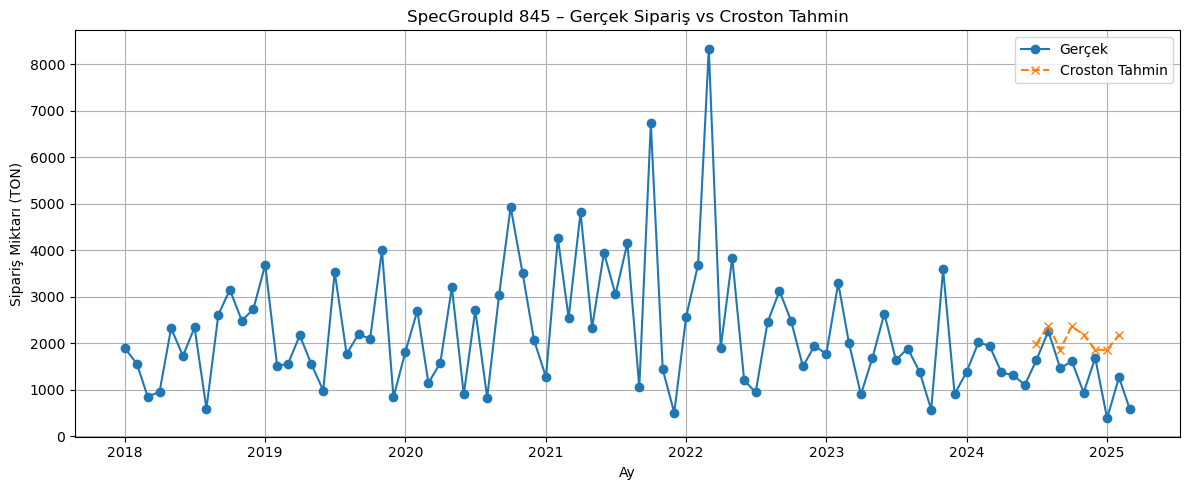

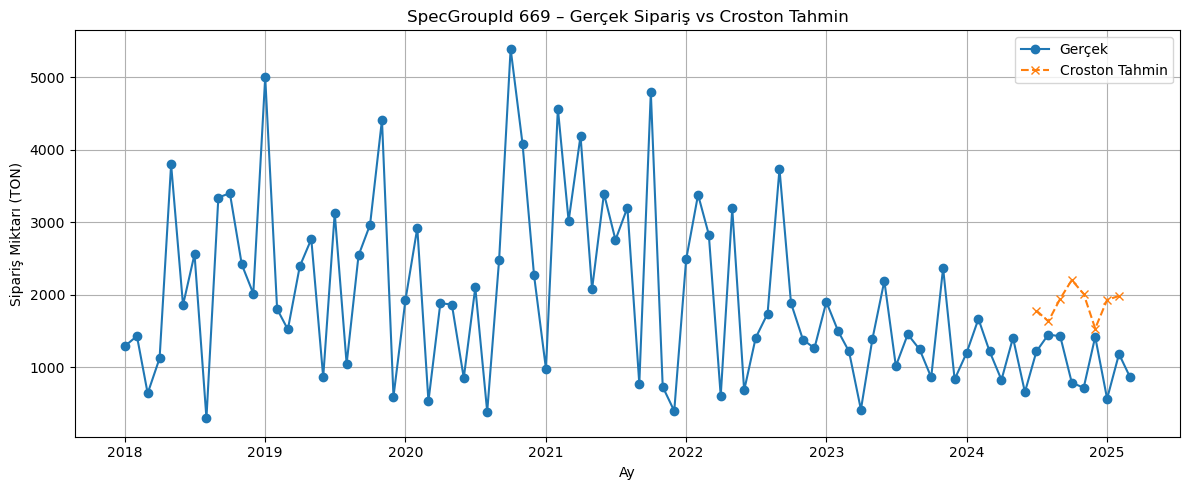

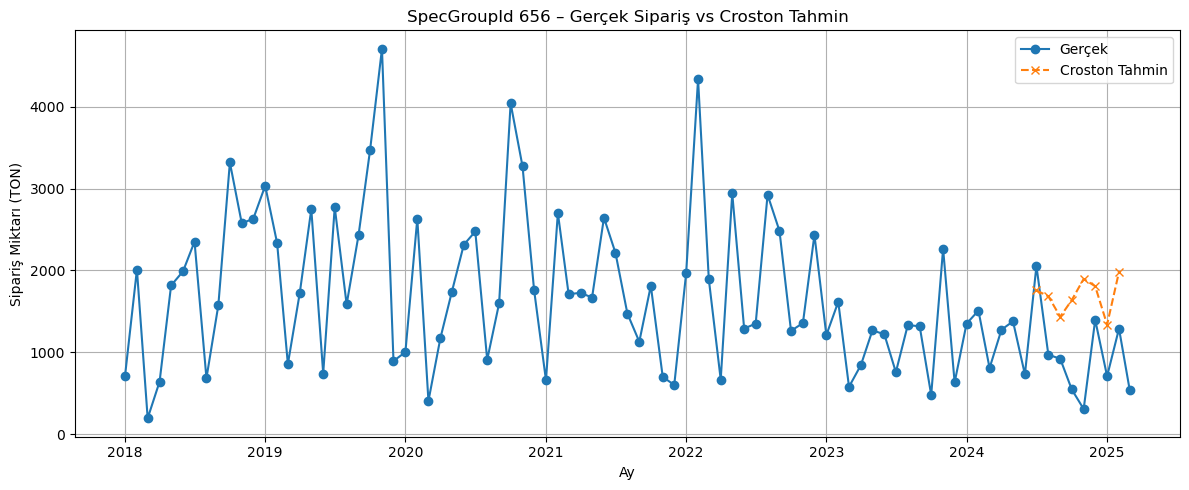

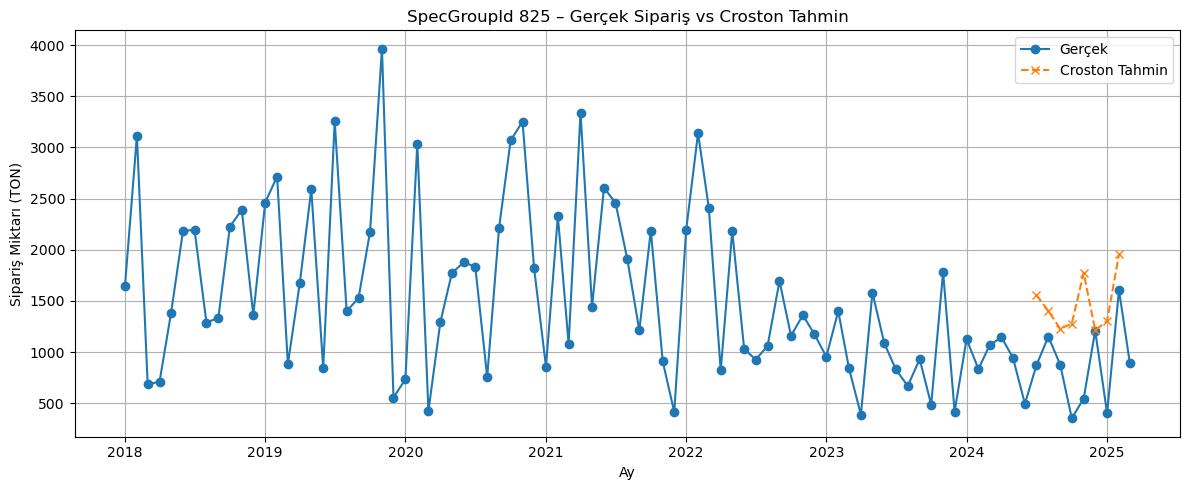

In [20]:
import matplotlib.pyplot as plt

# 🎯 Croston tahmini yapılan SpecGroupId'leri görselleştir
selected_spec_ids = ['166', '845', '669','656','825']

for spec_id in selected_spec_ids:
    actual_series = df[df['SpecGroupId'] == spec_id][['Month', 'Sipariş Mik. (TON)']].copy()
    actual_series = actual_series.groupby('Month').sum().sort_index()
    actual_series.rename(columns={'Sipariş Mik. (TON)': 'Actual'}, inplace=True)

    forecast_series = disaggregated_df[disaggregated_df['SpecGroupId'] == spec_id][['Month', 'Forecast_TON']].copy()
    forecast_series = forecast_series.groupby('Month').sum().sort_index()
    forecast_series.rename(columns={'Forecast_TON': 'Croston Forecast'}, inplace=True)

    merged = pd.concat([actual_series, forecast_series], axis=1)

    plt.figure(figsize=(12, 5))
    plt.plot(merged.index, merged['Actual'], label='Gerçek', marker='o')
    plt.plot(merged.index, merged['Croston Forecast'], label='Croston Tahmin', linestyle='--', marker='x')
    plt.title(f"SpecGroupId {spec_id} – Gerçek Sipariş vs Croston Tahmin")
    plt.xlabel("Ay")
    plt.ylabel("Sipariş Miktarı (TON)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [21]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

selected_spec_ids = ['166', '845', '669','656','825']
metrics_df = pd.DataFrame(columns=['SpecGroupId', 'MAE', 'MAPE (%)', 'sMAPE (%)', 'wMAPE (%)', 'RMSE'])

for spec_id in selected_spec_ids:
    actual_series = df[df['SpecGroupId'] == spec_id][['Month', 'Sipariş Mik. (TON)']].copy()
    actual_series = actual_series.groupby('Month').sum().sort_index()
    actual_series.rename(columns={'Sipariş Mik. (TON)': 'Actual'}, inplace=True)

    forecast_series = disaggregated_df[disaggregated_df['SpecGroupId'] == spec_id][['Month', 'Forecast_TON']].copy()
    forecast_series = forecast_series.groupby('Month').sum().sort_index()
    forecast_series.rename(columns={'Forecast_TON': 'Forecast'}, inplace=True)

    merged = pd.concat([actual_series, forecast_series], axis=1).dropna()

    if len(merged) == 0:
        continue

    mae = mean_absolute_error(merged['Actual'], merged['Forecast'])
    mape = mean_absolute_percentage_error(merged['Actual'], merged['Forecast']) * 100
    rmse = np.sqrt(mean_squared_error(merged['Actual'], merged['Forecast']))
    smape = 100 * np.mean(2 * np.abs(merged['Forecast'] - merged['Actual']) /
                          (np.abs(merged['Actual']) + np.abs(merged['Forecast'])))
    wmape = 100 * np.sum(np.abs(merged['Forecast'] - merged['Actual'])) / np.sum(np.abs(merged['Actual']))

    metrics_df = metrics_df.append({
        'SpecGroupId': spec_id,
        'MAE': mae,
        'MAPE (%)': mape,
        'sMAPE (%)': smape,
        'wMAPE (%)': wmape,
        'RMSE': rmse
    }, ignore_index=True)

# 📊 Sonuçları göster
print("📈 Croston – SpecGroupId Bazlı Performans:")
print(metrics_df)


📈 Croston – SpecGroupId Bazlı Performans:
  SpecGroupId          MAE    MAPE (%)  sMAPE (%)  wMAPE (%)         RMSE
0         166  4925.617605   72.298243  69.505180  57.215330  5856.332316
1         845   679.171431   86.985608  45.028858  48.267074   825.254361
2         669   781.469914   96.093471  54.543988  71.107403   922.453616
3         656   742.468100  129.264955  60.866818  72.513519   838.582444
4         825   587.239476  109.398669  56.849120  67.016923   703.382871


/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_28204/2623431746.py:29: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_28204/2623431746.py:29: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_28204/2623431746.py:29: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.append({
/var/folders/pr/gmpf2b597dq2lqlfs27mkh3c0000gn/T/ipykernel_28204/2623431746.py:29: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  metrics_df = metrics_df.appen

In [22]:
#OVERFIT TEST
import pandas as pd
import numpy as np

# Excel dosyasını oku
df = pd.read_excel("../preprocessedBelgeler/zero_filled_forecastData_altLimit100_son3_byGrup.xlsx")  # kendi dosya yolunu yaz

# Gerekli kolonları adlandır ve temizle
df.columns = ['Month', 'SpecGroupId', 'Grade', 'Sipariş Mik. (TON)']
df['Month'] = pd.to_datetime(df['Month'])
df['SpecGroupId'] = df['SpecGroupId'].astype(str)

# Grade bazında aylık talep hesapla
monthly_grade = df.groupby(['Month', 'Grade'])['Sipariş Mik. (TON)'].sum().reset_index()


FileNotFoundError: [Errno 2] No such file or directory: '../preprocessedBelgeler/zero_filled_forecastData_altLimit100_son3_byGrup.xlsx'

In [ ]:
train_forecast_df = pd.DataFrame()
grade_list = monthly_grade['Grade'].unique()

for grade in grade_list:
    # Eğitim aralığını filtrele
    grade_data = monthly_grade[
        (monthly_grade['Grade'] == grade) &
        (monthly_grade['Month'] >= '2022-01') &
        (monthly_grade['Month'] <= '2024-05')
    ].copy()

    if grade_data.empty:
        continue

    # Zaman serisi olarak oluştur
    y_train = grade_data.set_index('Month').asfreq('MS')['Sipariş Mik. (TON)'].fillna(0).values

    # Croston sabit tahmin değeri: mean(demand) / mean(interval)
    demand_vals = y_train[y_train > 0]
    demand_idxs = np.where(y_train > 0)[0]

    if len(demand_vals) < 2:
        continue

    avg_demand = np.mean(demand_vals)
    avg_interval = np.mean(np.diff(demand_idxs))
    croston_val = avg_demand / avg_interval if avg_interval > 0 else 0

    # Eğitim ayları
    months = pd.date_range(start='2022-01-01', end='2024-05-01', freq='MS')

    # Tahminleri yaz
    temp_df = pd.DataFrame({
        'Month': months,
        'Grade': grade,
        'Forecast_TON': [croston_val] * len(months)
    })

    train_forecast_df = pd.concat([train_forecast_df, temp_df], ignore_index=True)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

# Gerçek eğitim verileri
actual_train = monthly_grade[
    (monthly_grade['Month'] >= '2022-01') &
    (monthly_grade['Month'] <= '2024-05')
]

# Birleştir
merged_train = pd.merge(
    actual_train,
    train_forecast_df,
    on=['Month', 'Grade'],
    how='inner'
)

# Karşılaştırılabilir seriler
y_true = merged_train['Sipariş Mik. (TON)']
y_pred = merged_train['Forecast_TON']

# Hata metrikleri
mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred) * 100
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
wmape = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))

# Yazdır
print("\n📚 CROSTON OVERFIT TESTİ – Eğitim Seti")
print(f"MAE   : {mae:.2f}")
print(f"MAPE  : {mape:.2f}%")
print(f"sMAPE : {smape:.2f}%")
print(f"wMAPE : {wmape:.2f}%")
print(f"RMSE  : {rmse:.2f}")


In [ ]:
import matplotlib.pyplot as plt

# 🎯 Croston'ın eğitim aralığında kalan ayları seç
target_months = ['2022-07', '2023-03', '2024-01']

for month in target_months:
    print(f"⏳ {month} ayı için CROSTON overfit grafiği hazırlanıyor...")

    forecast_m = train_forecast_df[train_forecast_df['Month'] == pd.to_datetime(month)]
    actual_m = monthly_grade[monthly_grade['Month'] == pd.to_datetime(month)]

    forecast_m = forecast_m[['Grade', 'Forecast_TON']].set_index('Grade')
    actual_m = actual_m[['Grade', 'Sipariş Mik. (TON)']].set_index('Grade')

    common_grades = forecast_m.index.intersection(actual_m.index)

    if len(common_grades) == 0:
        print(f"⚠️ {month} için hem tahmin hem gerçek veri yok.")
        continue

    compare_df = pd.DataFrame({
        'Croston Tahmin': forecast_m.loc[common_grades]['Forecast_TON'],
        'Gerçek': actual_m.loc[common_grades]['Sipariş Mik. (TON)']
    }).sort_index()

    # Grafik
    compare_df.plot(kind='bar', figsize=(12,6), color=['#1f77b4', '#ff7f0e'])
    plt.title(f"{month} - Grade Bazlı Croston Overfit Testi")
    plt.ylabel("Sipariş Miktarı (TON)")
    plt.xlabel("Grade")
    plt.xticks(rotation=45)
    plt.legend(["Tahmin", "Gerçek"])
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.show()


In [ ]:
import matplotlib.pyplot as plt

# 🎯 Croston tahminine göre çizmek istediğin SpecGroupId'ler
selected_spec_ids = [ '166', '845', '669','656','825']

for spec_id in selected_spec_ids:
    # 🔹 Gerçek veriler (geçmiş)
    actual_series = df[df['SpecGroupId'] == spec_id][['Month', 'Sipariş Mik. (TON)']].copy()
    actual_series = actual_series.groupby('Month').sum().sort_index()
    actual_series.rename(columns={'Sipariş Mik. (TON)': 'Actual'}, inplace=True)

    # 🔹 Croston tahmin verileri (disaggregated_df kullanılıyor!)
    forecast_series = disaggregated_df[disaggregated_df['SpecGroupId'] == spec_id][['Month', 'Forecast_TON']].copy()
    forecast_series = forecast_series.groupby('Month').sum().sort_index()
    forecast_series.rename(columns={'Forecast_TON': 'Croston Forecast'}, inplace=True)

    # 🔗 Birleştir
    merged = pd.concat([actual_series, forecast_series], axis=1)

    # 📈 Grafik
    plt.figure(figsize=(12, 5))
    plt.plot(merged.index, merged['Actual'], label='Gerçek', marker='o')
    plt.plot(merged.index, merged['Croston Forecast'], label='Croston Tahmin', linestyle='--', marker='x')
    plt.title(f"SpecGroupId {spec_id} – Gerçek Sipariş vs Croston Tahmin")
    plt.xlabel("Ay")
    plt.ylabel("Sipariş Miktarı (TON)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
